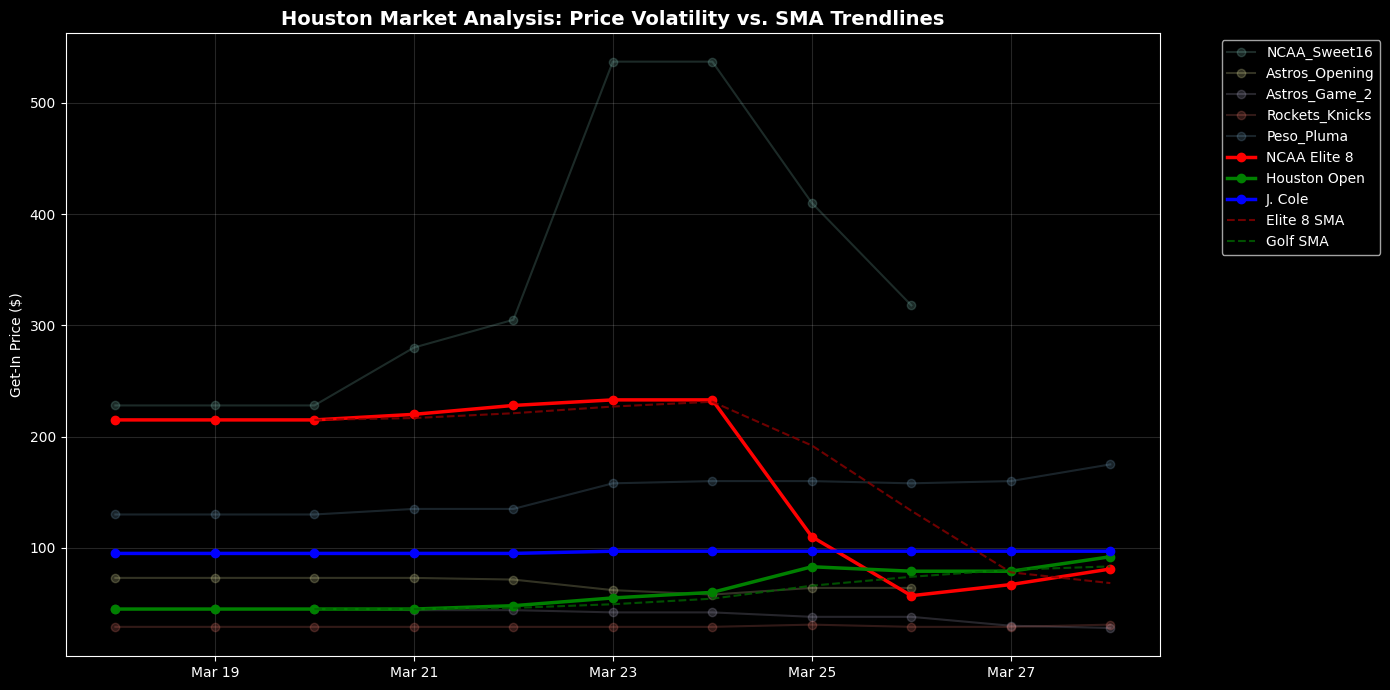


                            🚀 HOUSTON MARKET AUDIT: FINAL PUSH                            
EVENT              | START    | LAST PRICE     | 3-DAY SMA    | TOTAL CHG
------------------------------------------------------------------------------------------
NCAA_Sweet16       | $228     | $318                  | N/A          |    39.5% 📈
NCAA_Elite8        | $215     | $81                   | $68.33       |   -62.3% 📉
Astros_Opening     | $73      | $64                   | N/A          |   -12.3% 📉
Astros_Game_2      | $45      | $28                   | N/A          |   -37.8% 📉
Rockets_Knicks     | $29      | $31                   | N/A          |     6.9% 📈
Peso_Pluma         | $130     | $175                  | N/A          |    34.6% 📈
Houston_Open       | $45      | $92                   | $83.33       |   104.4% 📈
J_Cole_Toyota      | $95      | $97                   | $97.00       |     2.1% 📈


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

def run_houston_market_final_push():
    # 1. LIVE DATA ENTRY (Verified March 28, 2026)
    houston_trends = {
        'NCAA_Sweet16':   [228, 228, 228, 280, 305, 537, 537, 410, 318, None, None],
        'NCAA_Elite8':    [215, 215, 215, 220, 228, 233, 233, 110, 57, 67, 81],
        'Astros_Opening': [73, 73, 73, 73, 71.5, 62, 58, 64, 64, None, None],
        'Astros_Game_2':  [45, 45, 45, 44, 44, 42, 42, 38, 38, 30, 28],
        'Rockets_Knicks': [29, 29, 29, 29, 29, 29, 29, 31, 29, 29, 31],
        'Peso_Pluma':     [130, 130, 130, 135, 135, 158, 160, 160, 158, 160, 175],
        'Houston_Open':   [45, 45, 45, 45, 48, 55, 60, 83, 79, 79, 92],
        'J_Cole_Toyota':  [95, 95, 95, 95, 95, 97, 97, 97, 97, 97, 97]  # Added J. Cole Anchor
    }

    # 2. DATE ALIGNMENT
    today = datetime(2026, 3, 28)
    data_length = len(houston_trends['NCAA_Elite8'])
    date_list = [(today - timedelta(days=i)).strftime("%Y-%m-%d") for i in range(data_length - 1, -1, -1)]
    df = pd.DataFrame(houston_trends, index=pd.to_datetime(date_list))

    # 3. SMA CALCULATIONS (Smoothing 3-Day Windows)
    df['Elite8_Trend'] = df['NCAA_Elite8'].rolling(window=3).mean()
    df['Golf_Trend']   = df['Houston_Open'].rolling(window=3).mean()
    df['Cole_Trend']   = df['J_Cole_Toyota'].rolling(window=3).mean()

    # --- VISUALIZATION ---
    plt.figure(figsize=(14, 7))

    # Plot Background Events (Dimmed)
    for event in ['NCAA_Sweet16', 'Astros_Opening', 'Astros_Game_2', 'Rockets_Knicks', 'Peso_Pluma']:
        valid = df[event].dropna()
        plt.plot(valid.index, valid.values, marker='o', alpha=0.2, label=event)

    # Plot Target Events (Bold)
    plt.plot(df.index, df['NCAA_Elite8'], marker='o', color='red', linewidth=2.5, label='NCAA Elite 8')
    plt.plot(df.index, df['Houston_Open'], marker='o', color='green', linewidth=2.5, label='Houston Open')
    plt.plot(df.index, df['J_Cole_Toyota'], marker='o', color='blue', linewidth=2.5, label='J. Cole')

    # Plot Trendlines (SMA)
    plt.plot(df.index, df['Elite8_Trend'], color='darkred', linestyle='--', alpha=0.8, label='Elite 8 SMA')
    plt.plot(df.index, df['Golf_Trend'], color='darkgreen', linestyle='--', alpha=0.8, label='Golf SMA')

    # Formatting
    plt.title('Houston Market Analysis: Price Volatility vs. SMA Trendlines', fontsize=14, fontweight='bold')
    plt.ylabel('Get-In Price ($)')
    plt.grid(True, alpha=0.15)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('houston_market_analysis.png')
    plt.show()

    # --- TERMINAL REPORT ---
    print("\n" + "🚀 HOUSTON MARKET AUDIT: FINAL PUSH".center(90))
    print("="*90)
    print(f"{'EVENT':<18} | {'START':<8} | {'LAST PRICE':<14} | {'3-DAY SMA':<12} | {'TOTAL CHG'}")
    print("-" * 90)

    for event in houston_trends.keys():
        prices = df[event].dropna().values
        p_start, p_last = prices[0], prices[-1]

        # Match SMA columns
        ma_col = {'NCAA_Elite8': 'Elite8_Trend', 'Houston_Open': 'Golf_Trend', 'J_Cole_Toyota': 'Cole_Trend'}.get(event)
        ma_val = f"${df[ma_col].iloc[-1]:.2f}" if ma_col and not np.isnan(df[ma_col].iloc[-1]) else "N/A"

        status = "" if df[event].iloc[-1] is not None else " (Final)"
        chg = ((p_last - p_start) / p_start) * 100
        icon = "📈" if chg > 0 else "📉"

        print(f"{event:<18} | ${p_start:<7.0f} | ${p_last:<13.0f}{status:<7} | {ma_val:<12} | {chg:>7.1f}% {icon}")

run_houston_market_final_push()